<div align="center">
  <a href="https://colab.research.google.com/github/PrunaAI/ai-efficiency-courses/blob/main/solutions/04-benchmark_llm_quantization_methods.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
  </a>
</div>

---
**💡 Tip**: Click the button above to open this notebook in Google Colab for free GPU access!

## Installation

This notebook includes automatic setup cells that will install the project from git repository with UV.

**Note**: Run the setup cells below before starting the exercises.

In [ ]:
# Install project directly from git repository
!uv pip install git+https://github.com/PrunaAI/ai-efficiency-courses.git

## Utility cells

During the course, we'll leverage some course utilities to streamline our workflow. These utilities are located in the `course` package, which can simply be imported given that we installed the project from git repository above.
You can find the source code [here](https://github.com/PrunaAI/ai-efficiency-courses/tree/main/course).

These utilities will help us:
- Load and manage lists of model ids that we have verified to work.
- Generate informative plots for model analysis.
- Iterate efficiently over evaluation and model configuration options.

Let's first load our models. We will use `SMALL_MODEL_IDS`, which are sub 1B parameters which should be easy to download and load into memory. We recommend starting with these smaller models but feel free to experiment with other models until you reach your GPU memory limit!

In [ ]:
from course import SMALL_MODEL_IDS, MEDIUM_MODEL_IDS, LARGE_MODEL_IDS, ALL_MODEL_IDS

MODEL_IDS = SMALL_MODEL_IDS
# MODEL_IDS = MEDIUM_MODEL_IDS
# MODEL_IDS = LARGE_MODEL_IDS
# MODEL_IDS = ALL_MODEL_IDS

MODEL_IDS

We also recommend to set a custom cache directory for models. Loading models can take significant disk space. To avoid filling up your default disk, we recommend setting a custom cache directory for downloaded models. You can do this by running the following in a terminal or in a notebook cell:

In [ ]:
# Replace <path_to_cache> with your desired cache path
import os

CACHE_PATH = "<path_to_cache>"
os.environ["TORCH_HOME"] = CACHE_PATH
os.environ["HF_HOME"] = CACHE_PATH
os.environ["HUGGINGFACE_HUB_CACHE"] = CACHE_PATH
os.environ["HUGGINGFACE_ASSETS_CACHE"] = CACHE_PATH
os.environ["TRANSFORMERS_CACHE"] = CACHE_PATH

You can also clear the cache by running the following cell:

In [ ]:
from course.models import clear_cache

clear_cache("<path_to_cache>")

# 04: Benchmark LLM Quantization Methods

Welcome to the fourth lecture of the AI Efficiency course! 🚀

In this tutorial, we'll explore and benchmark different quantization methods for Large Language Models (LLMs). Understanding how quantization impacts model performance and efficiency is essential for anyone looking to deploy LLMs in resource-constrained environments or optimize inference speed and memory usage.

By the end of this lecture, you will:
- Learn what quantization is and why it matters for LLMs.
- Benchmark and compare various quantization techniques.
- Gain hands-on experience evaluating the trade-offs between model size, speed, and accuracy.

Let's dive in and discover how quantization can make LLMs more efficient!

## 1. Imports

As we've already installed the project, we can import the necessary libraries. We will be using `torch`, `transformers` and `pruna` for this tutorial as interfaces to the model and tokenizer. On top of that, we will be using `matplotlib` for basic plotting. Feel free to add any other libraries you might need.

In [1]:
import copy

import matplotlib.pyplot as plt
from pruna import SmashConfig, smash
from transformers import AutoModelForCausalLM

Multiple distributions found for package optimum. Picked distribution: optimum


From the `course` package, we will be providing the `evaluate_model` function. This function takes a model id or an optimized `PrunaModel` and evaluates it using the a list of `PrunaMetric`s and a `PrunaDataModule`. If you don't want to provide any metrics of PrunaDataModule, the function will use a set of default metrics and the `WikiText` dataset.

Let's load our first model and evaluate it. For now, we will not provide any metrics or evaluation dataset, but we'll get to that later.

In [ ]:
from course import evaluate_model

### To Complete ###

### 3. Benchmarking LLM Quantization Methods

In this section, you'll learn how to systematically benchmark different quantization strategies for large language models (LLMs).

As you complete this section, refer to the [Pruna documentation](https://docs.pruna.ai/en/stable/docs_pruna/user_manual/configure.html) for detailed guidance on AI efficiency algorithms and defining smash configurations.

### 3.1 Quantization Configurations

First, you'll experiment with defining quantization methods for the base model using a `SmashConfig` object. You'll need to explore the different quantization methods and their parameters using the [Pruna compression documentation](https://docs.pruna.ai/en/stable/compression.html). Some algorithms require a tokenizer and a dataset to be added to the `SmashConfig` object as the quantization relies on aligning the weights of the model with the provided dataset.

**Why is this important?**  
Quantization is a key technique for improving the efficiency of LLMs, enabling faster inference and reduced memory usage. By comparing various quantization methods, you can make informed decisions about which approach best balances performance and resource constraints for your use case.

**Your tasks:**
1. Set up several configurations for popular quantization methods : `llm_int8`, `gptq`, `hqq`, `awq`, and `quanto`.
2. Make sure to add the tokenizer and the dataset to the `SmashConfig` object when needed.

**Key questions to consider:**
- What are differences between the different quantization methods?
- What could be the impacts of the different algorithm parameters on the model's efficiency and performance?

As you work through this, observe how each quantization strategy changes the model's efficiency and discuss your findings.

In [ ]:
# Create list of SmashConfig with different quantization methods
smash_configs = []
model_id = MODEL_IDS[0]

### To Complete ###

### 3.2 Evaluate quantization configurations

In this section, you'll apply each quantization configuration to the base model and evaluate their performance using the `evaluate_model` function on GPU.

**Tasks:**
1. For each quantization configuration in your `smash_configs` list, quantize the base model.
2. Evaluate each quantized model on the `"WikiText"` dataset using the `evaluate_model` function.
3. Collect and compare the results for the following metrics:
   - Inference memory usage
   - Inference speed (latency)
   - Energy consumption
   - Perplexity

**Discussion points:**
- Which quantization method results in the lowest memory usage?
- Which method provides the fastest inference?
- Which method is most energy efficient?
- Which method achieves the best perplexity score?

As you complete this section, observe and discuss how each quantization strategy impacts the model's efficiency and performance. Make sure to copy the model before applying a new quantization configuration to avoid any side effects.

In [ ]:
from course import evaluate_model


def evaluate_configs(
    pretrained_model_name_or_path, smash_configs, metrics=None, dataset="WikiText"
):
    """Evaluate multiple quantization configurations on a model.

    Args:
        model: The base model to quantize and evaluate
        smash_configs: List of SmashConfig objects containing quantization settings
        metrics: List of metrics to evaluate (default: None)
        dataset: Name of dataset to evaluate on (default: "WikiText")

    Returns:
        dict: Results dictionary mapping quantizer names to evaluation metrics
    """
    results = {}

    ### To Complete ###

### 3.3 Visualize and compare quantized LLMs using a Pareto front

In this section, you'll visualize the trade-offs between different quantization strategies by plotting their performance metrics on a Pareto front.

**Tasks:**
- Create a Pareto front plot using the evaluation metrics from the previous step. You may use the saved results files if available.
- Clearly label each quantization method on the plot for easy comparison.

**Discussion:**
- Which quantization configuration offers the best balance between the selected metrics (i.e., lies on the Pareto front)?

In [ ]:
def plot_pareto_front(results, metric1_name, metric2_name):
    """
    Plot a pareto front comparing two metrics across different quantization methods.

    Args:
        results (dict): Dictionary mapping quantizer names to their evaluation results
        metric1_name (str): Name of the first metric to plot on x-axis
        metric2_name (str): Name of the second metric to plot on y-axis

    Creates a scatter plot showing the tradeoff between the two metrics for each quantizer,
    with points labeled by quantizer name. Includes a grid and appropriate axis labels.
    """
    # Extract metrics for each quantizer
    quantizers = []
    metric1_values = []
    metric2_values = []

    for quantizer, result in results.items():
        if result is not None and metric1_name in result and metric2_name in result:
            quantizers.append(quantizer)
            metric1_values.append(result[metric1_name])
            metric2_values.append(result[metric2_name])

    plt.figure(figsize=(10, 6))
    plt.scatter(metric1_values, metric2_values)
    for i, quantizer in enumerate(quantizers):
        plt.annotate(
            quantizer,
            (metric1_values[i], metric2_values[i]),
            xytext=(5, 5),
            textcoords="offset points",
        )
    plt.xlabel(metric1_name)
    plt.ylabel(metric2_name)
    plt.title(f"Pareto Front: {metric1_name} vs {metric2_name}")
    plt.grid(True, linestyle="--", alpha=0.7)

    plt.show()

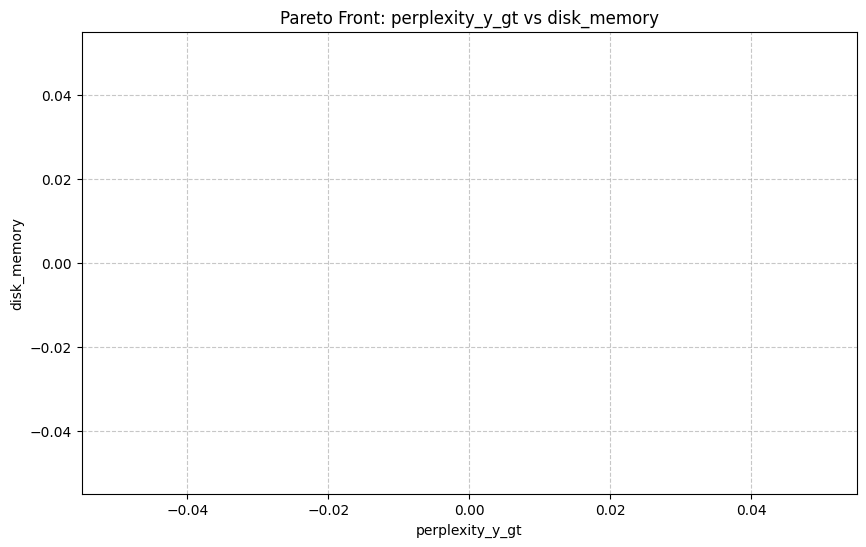

In [ ]:
plot_pareto_front(evaluation_results, "perplexity_y_gt", "disk_memory")

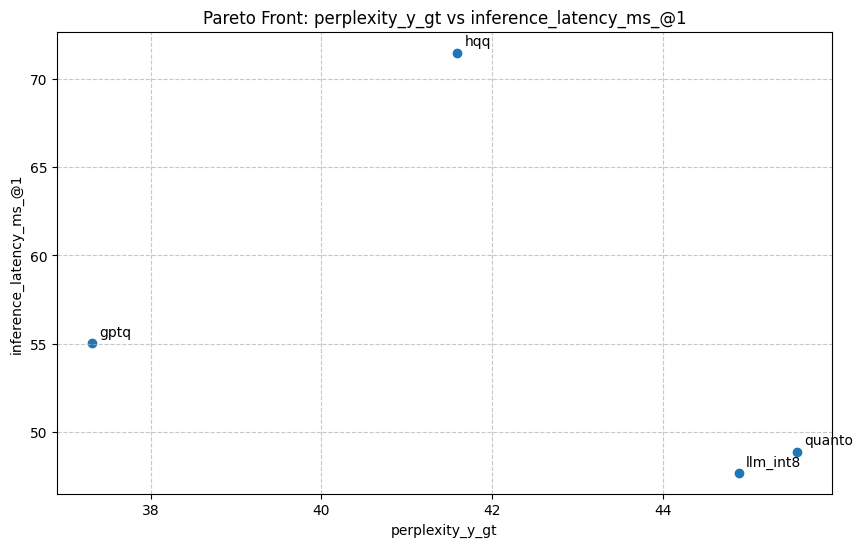

In [ ]:
plot_pareto_front(evaluation_results, "perplexity_y_gt", "inference_latency_ms_@1")